In [ ]:
!pip show matplotlib seaborn scikit-learn tensorflow


Name: matplotlib
Version: 3.10.0
Summary: Python plotting package
Home-page: https://matplotlib.org
Author: John D. Hunter, Michael Droettboom
Author-email: Unknown <matplotlib-users@python.org>
License: License agreement for matplotlib versions 1.3.0 and later

 1. This LICENSE AGREEMENT is between the Matplotlib Development Team
 ("MDT"), and the Individual or Organization ("Licensee") accessing and
 otherwise using matplotlib software in source or binary form and its
 associated documentation.

 2. Subject to the terms and conditions of this License Agreement, MDT
 hereby grants Licensee a nonexclusive, royalty-free, world-wide license
 to reproduce, analyze, test, perform and/or display publicly, prepare
 derivative works, distribute, and otherwise use matplotlib
 alone or in any derivative version, provided, however, that MDT's
 License Agreement and MDT's notice of copyright, i.e., "Copyright (c)
 2012- Matplotlib Development Team; All Rights Reserved" are retained in
 matplotlib

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version: {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs available: {len(gpus)}')

TensorFlow version: 2.20.0
GPUs available: 2


In [ ]:
results_dir = "results/Cracked/"
if not os.path.exists(results_dir):
    os.makedirs(results_dir, exist_ok=True)

In [ ]:
!nvidia-smi
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'\nGPUs available: {len(gpus)}')
    for gpu in gpus:
        print(f' - {gpu}')
else:
    print('\nNo GPU found — training will run on CPU (slower).')

Thu Jul 30 05:12:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
from pathlib import Path


kaggle_input_path = "/kaggle/input/datasets/arunrk7/surface-crack-detection"
base_path = Path(kaggle_input_path)

print(f"Checking Base Directory: {base_path}")
print("-" * 50)

if base_path.exists():
    for class_folder in os.listdir(base_path):
        folder_path = base_path / class_folder

        if folder_path.is_dir():
            jpg_count = len(list(folder_path.glob('*.jpg')))
            png_count = len(list(folder_path.glob('*.png')))
            jpeg_count = len(list(folder_path.glob('*.jpeg')))
            total_images = jpg_count + png_count + jpeg_count

            print(f"Class Folder Detected : '{class_folder}'")
            print(f" -> Valid Images Found: {total_images}")
            print("-" * 50)
else:
    print("Path does not exist! Please check the Kaggle input directory.")

Checking Base Directory: /kaggle/input/datasets/arunrk7/surface-crack-detection
--------------------------------------------------
Class Folder Detected : 'Negative'
 -> Valid Images Found: 20000
--------------------------------------------------
Class Folder Detected : 'Positive'
 -> Valid Images Found: 20000
--------------------------------------------------


In [ ]:
BASE_DIR = Path('/kaggle/input/datasets/arunrk7/surface-crack-detection')

IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
BATCH_SIZE = 64
EPOCHS = 50
LR = 1e-3
SEED = 42

print(f'Image size : {IMAGE_HEIGHT} x {IMAGE_WIDTH}')
print(f'Batch size : {BATCH_SIZE}')
print(f'Max epochs : {EPOCHS}')
print(f'Learning rate: {LR}')
print("-" * 50)

Image size : 128 x 128
Batch size : 64
Max epochs : 50
Learning rate: 0.001
--------------------------------------------------


In [ ]:
print("Loading Training Data:")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE
)

print("\nLoading Validation/Test Data:")
val_and_test_dataset = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE
)

val_batches = tf.data.experimental.cardinality(val_and_test_dataset)

val_dataset = val_and_test_dataset.take(val_batches // 2)

test_dataset = val_and_test_dataset.skip(val_batches // 2)

print(f"\nSuccessfully created 3 splits:")
print(f" - Validation batches: {tf.data.experimental.cardinality(val_dataset).numpy()}")
print(f" - Test batches: {tf.data.experimental.cardinality(test_dataset).numpy()}")

class_names = train_dataset.class_names
num_classes = len(class_names)
print(f'\nClasses ({num_classes}): {class_names}')

Loading Training Data:
Found 40000 files belonging to 2 classes.
Using 32000 files for training.


I0000 00:00:1785388402.006394      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785388402.009447      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Loading Validation/Test Data:
Found 40000 files belonging to 2 classes.
Using 8000 files for validation.

Successfully created 3 splits:
 - Validation batches: 62
 - Test batches: 63

Classes (2): ['Negative', 'Positive']


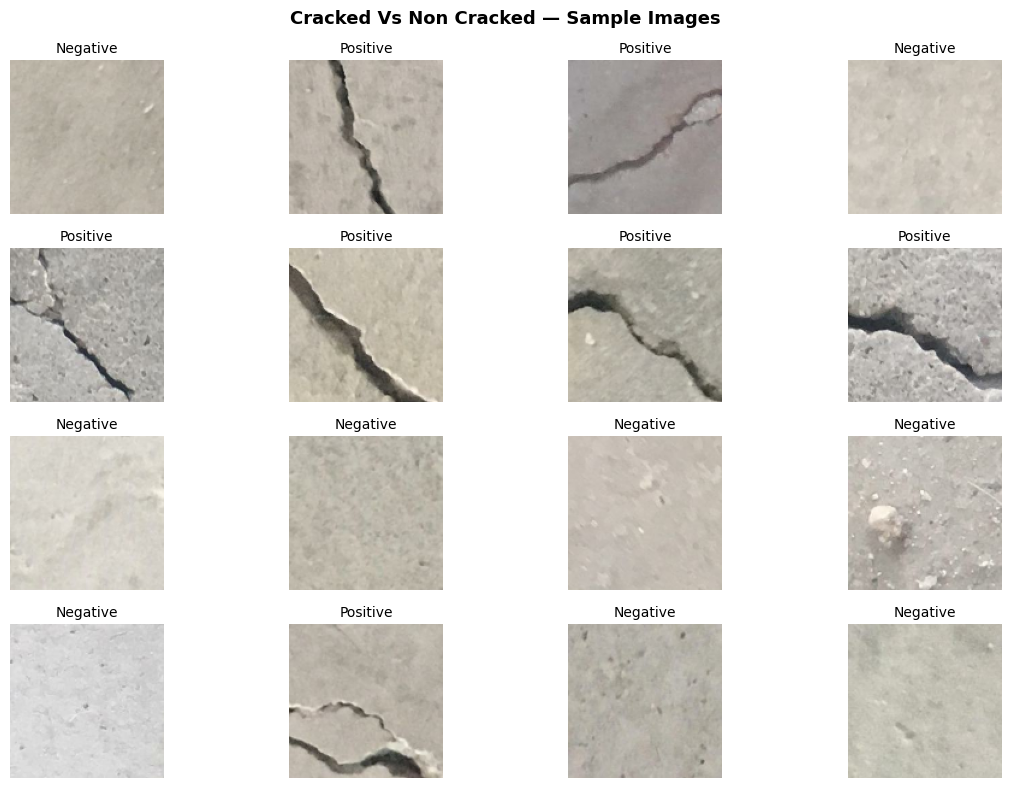

In [ ]:

for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    plt.title(class_names[fixed_labels[i]], fontsize=10)
    plt.axis('off')

plt.suptitle('Cracked Vs Non Cracked — Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{results_dir}lab8_samples.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)
print('\nPipeline optimised with cache + shuffle + prefetch.')


Pipeline optimised with cache + shuffle + prefetch.


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
], name='data_augmentation')

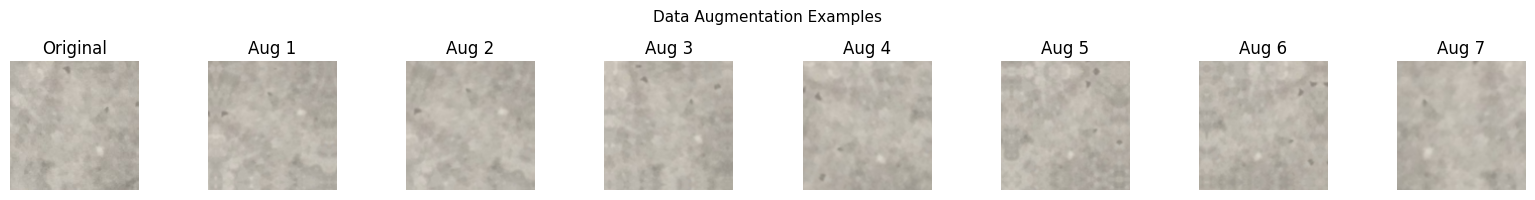

In [ ]:
for images, _ in train_dataset.take(1):
    sample = images[0:1]
    break

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
axes[0].imshow(sample[0].numpy().astype('uint8'))
axes[0].set_title('Original')
axes[0].axis('off')

for i in range(1, 8):
    aug_img = data_augmentation(sample, training=True)[0].numpy().astype('uint8')
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=11)
plt.tight_layout()
plt.savefig(f'{results_dir}lab8_augmentation.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
import os
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

models_dir = "/kaggle/working/models/"
os.makedirs(models_dir, exist_ok=True)

def make_callbacks(name):
    """Return a fresh set of callbacks for each model."""
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'{models_dir}{name}_best.keras',
            monitor='val_accuracy',
            save_best_only=True,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=8,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=4,
            min_lr=1e-7,
            verbose=1
        ),
    ]

def plot_learning_curves(history, title='Learning Curves'):
    """Plot accuracy and loss curves side-by-side."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, linestyle='--')
    plt.legend()
    plt.title(f'{title} — Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, linestyle='--')
    plt.legend()
    plt.title(f'{title} — Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{results_dir}lab8_{title.lower().replace(" ", "_")}_curves.png', dpi=120, bbox_inches='tight')
    plt.show()

def evaluate_model(model, dataset, class_names, title='Model'):
    """Evaluate a multiclass classification model."""
    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        preds = np.argmax(probs, axis=1)
        y_prob.append(probs)
        y_pred.append(preds)
        y_true.append(labels.numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)

    print(f"\n{title}")
    print(f'Accuracy  : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision : {precision_score(y_true, y_pred, average="weighted"):.4f}')
    print(f'Recall    : {recall_score(y_true, y_pred, average="weighted"):.4f}')
    print(f'F1-Score  : {f1_score(y_true, y_pred, average="weighted"):.4f}')
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm, cmap='Blues', cbar=False, annot=True, fmt='d',
        xticklabels=class_names, yticklabels=class_names,
        annot_kws={'fontsize': 12, 'fontweight': 'bold'}
    )
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'{results_dir}lab8_{title.lower().replace(" ", "_")}_confusion.png', dpi=120, bbox_inches='tight')
    plt.show()

    return accuracy_score(y_true, y_pred)

print('Callbacks and utility functions defined.')

Callbacks and utility functions defined.


In [ ]:
import tensorflow as tf

# STEP 20: Build the Custom CNN Architecture (THE MATHEMATICAL FIX)
def build_custom_cnn(input_shape, augmentation):
    inputs = tf.keras.Input(shape=input_shape)

    # Augmentation (active only during training)
    x = augmentation(inputs)
    x = tf.keras.layers.Rescaling(1.0 / 255)(x)


    BN_MOMENTUM = 0.99

    # Block 1: 32 filters
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization(momentum=BN_MOMENTUM)(x)
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization(momentum=BN_MOMENTUM)(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    # Block 2: 64 filters
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization(momentum=BN_MOMENTUM)(x)
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization(momentum=BN_MOMENTUM)(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    # Block 3: 128 filters
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization(momentum=BN_MOMENTUM)(x)
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization(momentum=BN_MOMENTUM)(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    # Classification Head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x) # Safe here at the end of the pipeline

    # Binary output
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs, name='custom_cnn_completely_fixed')

INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)
cnn_model = build_custom_cnn(INPUT_SHAPE, data_augmentation)

# Display the architecture
cnn_model.summary()

# STEP 21: Compile the model
print("\nCompiling Fixed Custom CNN...")
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

# STEP 22: Train the model
print("\nStarting Training for Fixed Custom CNN...")
cnn_history = cnn_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=make_callbacks('custom_cnn_completely_fixed'),
    verbose=1
)

Model: "custom_cnn_completely_fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 322,338 (1.23 MB)

 Trainable params: 321,442 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)


Compiling Fixed Custom CNN...

Starting Training for Fixed Custom CNN...
Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 98s 175ms/step - accuracy: 0.9869 - loss: 0.0403 - val_accuracy: 0.9786 - val_loss: 0.0872 - learning_rate: 0.0010
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 165ms/step - accuracy: 0.9946 - loss: 0.0187 - val_accuracy: 0.9851 - val_loss: 0.0530 - learning_rate: 0.0010
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 166ms/step - accuracy: 0.9953 - loss: 0.0166 - val_accuracy: 0.9937 - val_loss: 0.0135 - learning_rate: 0.0010
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 166ms/step - accuracy: 0.9964 - loss: 0.0141 - val_accuracy: 0.5910 - val_loss: 1.8727 - learning_rate: 0.0010
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 166ms/step - accuracy: 0.9959 - loss: 0.0146 - val_accuracy: 0.9975 - val_loss: 0.0087 - learning_rate: 0.0010
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 165ms/step - accuracy: 0.9968 - loss: 0.0128 - val_accuracy: 0.9960 - val_loss: 0.0119 - learning_rate: 0.0

Custom CNN -> val_loss: 0.0040
val_accuracy: 0.9997

Generating Learning Curves...


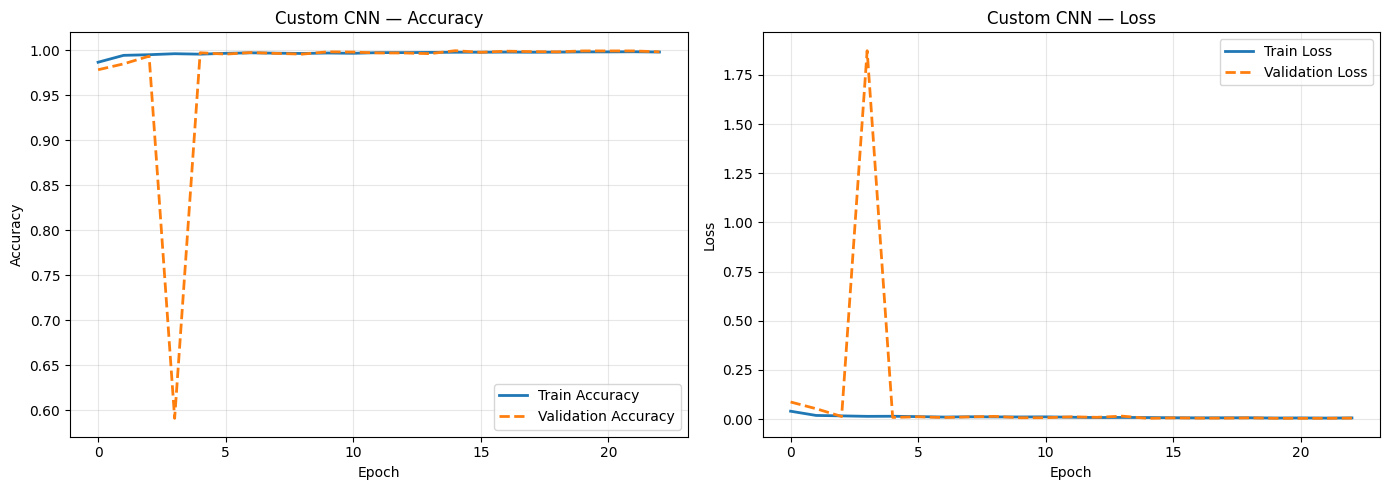


Evaluating Custom CNN on Test Dataset...

Custom CNN
Accuracy  : 0.9990
Precision : 0.9990
Recall    : 0.9990
F1-Score  : 0.9990

Classification Report:
              precision    recall  f1-score   support

    Negative     0.9995    0.9985    0.9990      1999
    Positive     0.9985    0.9995    0.9990      2033

    accuracy                         0.9990      4032
   macro avg     0.9990    0.9990    0.9990      4032
weighted avg     0.9990    0.9990    0.9990      4032



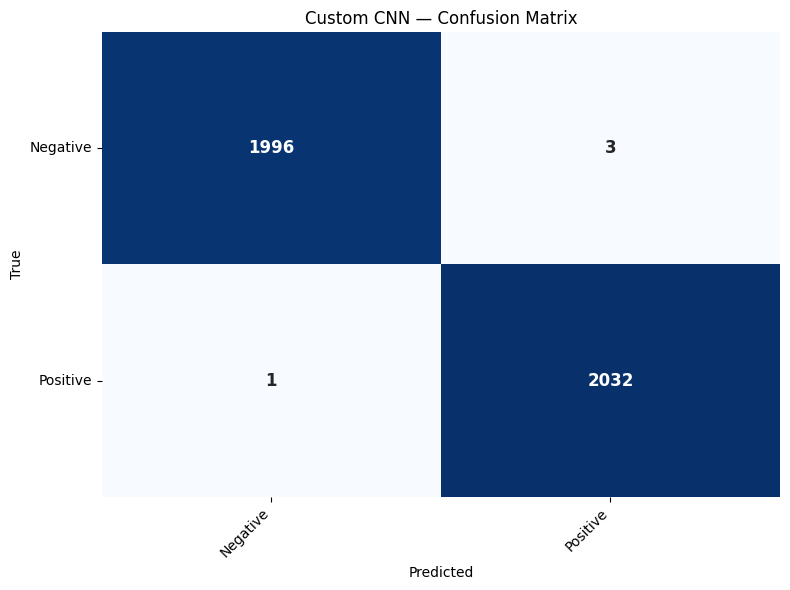

In [ ]:
cnn_val_loss, cnn_val_acc = cnn_model.evaluate(val_dataset, verbose=0)
print(f'Custom CNN -> val_loss: {cnn_val_loss:.4f}')
print(f'val_accuracy: {cnn_val_acc:.4f}')

print("\nGenerating Learning Curves...")
plot_learning_curves(cnn_history, 'Custom CNN')

print("\nEvaluating Custom CNN on Test Dataset...")
cnn_test_acc = evaluate_model(cnn_model, test_dataset, class_names, 'Custom CNN')

In [ ]:
def build_transfer_model(input_shape, augmentation, backbone='mobilenetv3small'):
    """
    Feature extraction model:
    1. Augment input (training only)
    2. Preprocess for MobileNetV3 (scales to [-1, 1])
    3. Frozen MobileNetV3Small backbone (no top)
    4. GlobalAveragePooling2D
    5. Dense classification head
    """
    if backbone == 'mobilenetv3small':
        base_model = tf.keras.applications.MobileNetV3Small(
            weights='imagenet',
            input_shape=input_shape,
            include_top=False,
        )
        preprocess_fn = tf.keras.applications.mobilenet_v3.preprocess_input
        model_name = 'mobilenetv3small_transfer'
    else:
        base_model = tf.keras.applications.MobileNetV2(
            weights='imagenet',
            input_shape=input_shape,
            include_top=False,
        )
        preprocess_fn = tf.keras.applications.mobilenet_v2.preprocess_input
        model_name = 'mobilenetv2_transfer'

    base_model.trainable = False
    print(f'Base model      : {base_model.name}')
    print(f'Trainable layers: {sum(1 for l in base_model.layers if l.trainable)} / {len(base_model.layers)}')

    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
    x = preprocess_fn(x)

    x = base_model(x, training=False)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs, name=model_name), base_model

tl_model, base_model = build_transfer_model(INPUT_SHAPE, data_augmentation, backbone='mobilenetv3small')
tl_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model      : MobileNetV3Small
Trainable layers: 0 / 157


Model: "mobilenetv3small_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 4, 4, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,087,346 (4.15 MB)

 Trainable params: 148,226 (579.01 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [ ]:
TL_LR = 1e-4

print("\nCompiling Transfer Learning Model...")
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=TL_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

print("\nStarting Feature Extraction Training...")
tl_history = tl_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=make_callbacks('tl_feature_extraction'),
    verbose=1,
)


Compiling Transfer Learning Model...

Starting Feature Extraction Training...
Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.9803 - loss: 0.0712 - val_accuracy: 0.9970 - val_loss: 0.0117 - learning_rate: 1.0000e-04
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9972 - loss: 0.0108 - val_accuracy: 0.9977 - val_loss: 0.0073 - learning_rate: 1.0000e-04
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9975 - loss: 0.0088 - val_accuracy: 0.9982 - val_loss: 0.0057 - learning_rate: 1.0000e-04
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9979 - loss: 0.0076 - val_accuracy: 0.9980 - val_loss: 0.0049 - learning_rate: 1.0000e-04
Epoch 5/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9982 - loss: 0.0070 - val_accuracy: 0.9980 - val_loss: 0.0042 - learning_rate: 1.0000e-04
Epoch 6/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9979 - loss: 0.0067 - val_accuracy: 0.9980 - val_loss: 0.0045 - lear

MobileNetV3 TL -> val_loss: 0.0023
MobileNetV3 TL -> val_accuracy: 0.9992

Generating Learning Curves...


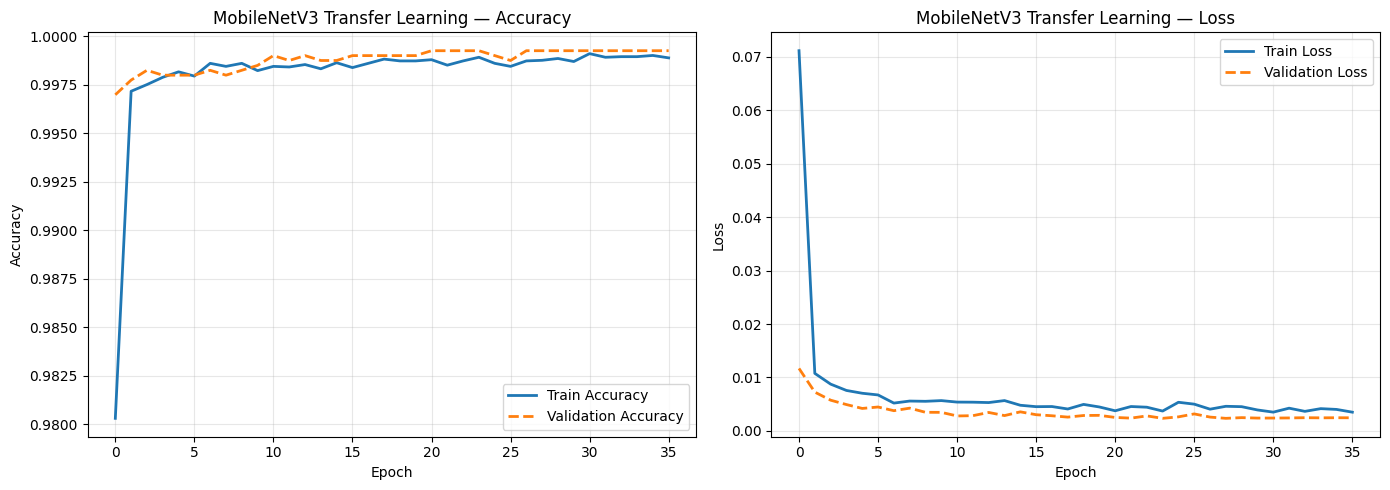


Evaluating MobileNetV3 TL on Test Dataset...

MobileNetV3 Transfer Learning
Accuracy  : 0.9993
Precision : 0.9993
Recall    : 0.9993
F1-Score  : 0.9993

Classification Report:
              precision    recall  f1-score   support

    Negative     1.0000    0.9985    0.9992      1999
    Positive     0.9985    1.0000    0.9993      2033

    accuracy                         0.9993      4032
   macro avg     0.9993    0.9992    0.9993      4032
weighted avg     0.9993    0.9993    0.9993      4032



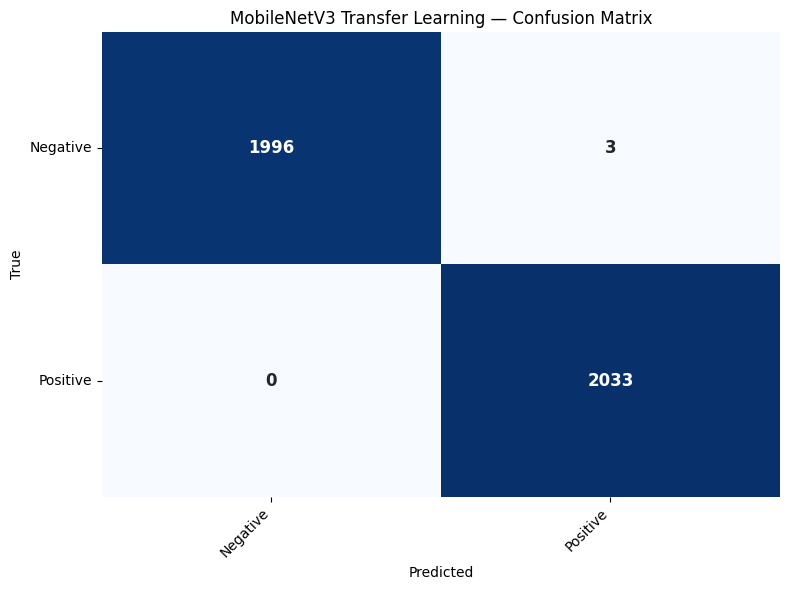

In [ ]:
tl_val_loss, tl_val_acc = tl_model.evaluate(val_dataset, verbose=0)
print(f'MobileNetV3 TL -> val_loss: {tl_val_loss:.4f}')
print(f'MobileNetV3 TL -> val_accuracy: {tl_val_acc:.4f}')

print("\nGenerating Learning Curves...")
plot_learning_curves(tl_history, 'MobileNetV3 Transfer Learning')

print("\nEvaluating MobileNetV3 TL on Test Dataset...")
tl_test_acc = evaluate_model(tl_model, test_dataset, class_names, 'MobileNetV3 Transfer Learning')

In [ ]:


print("Unfreezing the top 30 layers of the base model...")
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable base layers after unfreezing: {trainable_count} / {len(base_model.layers)}')

Unfreezing the top 30 layers of the base model...
Trainable base layers after unfreezing: 30 / 157


In [ ]:
FINETUNE_LR = TL_LR / 10

print(f"Recompiling with Fine-Tuning Learning Rate: {FINETUNE_LR}")
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

Recompiling with Fine-Tuning Learning Rate: 1e-05


In [ ]:

print("\nStarting Fine-Tuning Training Phase...")
ft_history = tl_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=make_callbacks('tl_finetuned'),
    verbose=2,
)


Starting Fine-Tuning Training Phase...
Epoch 1/20
500/500 - 26s - 51ms/step - accuracy: 0.9737 - loss: 0.0735 - val_accuracy: 0.9995 - val_loss: 0.0013 - learning_rate: 1.0000e-05
Epoch 2/20
500/500 - 15s - 30ms/step - accuracy: 0.9937 - loss: 0.0207 - val_accuracy: 0.9995 - val_loss: 0.0019 - learning_rate: 1.0000e-05
Epoch 3/20
500/500 - 15s - 30ms/step - accuracy: 0.9953 - loss: 0.0145 - val_accuracy: 0.9992 - val_loss: 0.0026 - learning_rate: 1.0000e-05
Epoch 4/20
500/500 - 15s - 30ms/step - accuracy: 0.9963 - loss: 0.0120 - val_accuracy: 0.9982 - val_loss: 0.0040 - learning_rate: 1.0000e-05
Epoch 5/20

Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
500/500 - 15s - 30ms/step - accuracy: 0.9966 - loss: 0.0112 - val_accuracy: 0.9982 - val_loss: 0.0044 - learning_rate: 1.0000e-05
Epoch 6/20
500/500 - 15s - 30ms/step - accuracy: 0.9968 - loss: 0.0099 - val_accuracy: 0.9980 - val_loss: 0.0050 - learning_rate: 3.0000e-06
Epoch 7/20
500/500 - 15s - 30ms/step

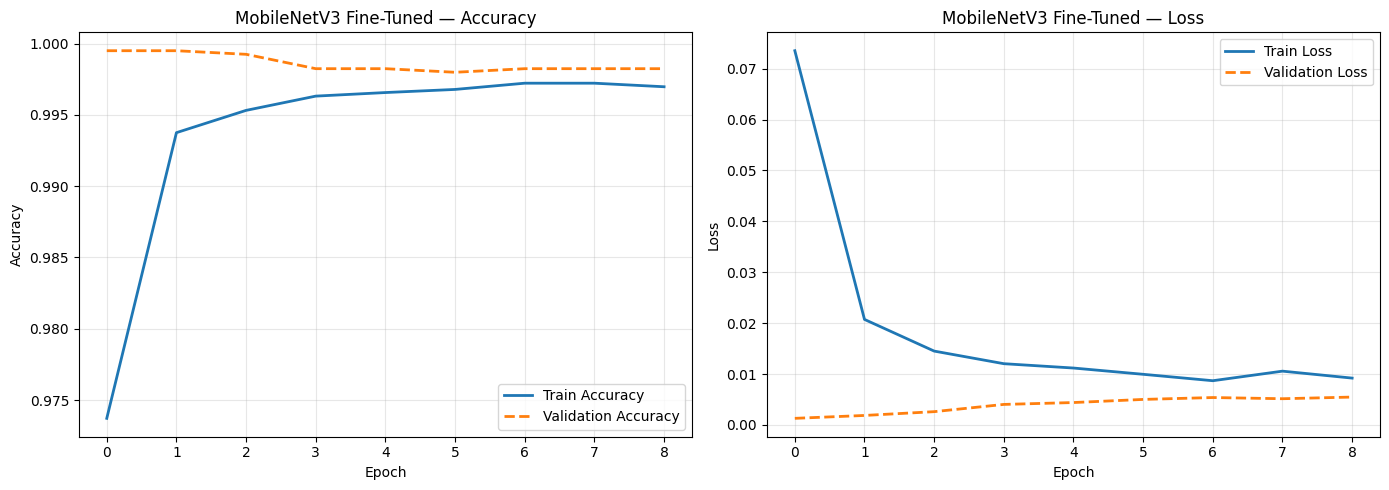

In [ ]:
plot_learning_curves(ft_history, 'MobileNetV3 Fine-Tuned')


Evaluating Fine-Tuned MobileNetV3 on Test Dataset...

MobileNetV3 Fine-Tuned
Accuracy  : 0.9993
Precision : 0.9993
Recall    : 0.9993
F1-Score  : 0.9993

Classification Report:
              precision    recall  f1-score   support

    Negative     0.9995    0.9990    0.9992      1999
    Positive     0.9990    0.9995    0.9993      2033

    accuracy                         0.9993      4032
   macro avg     0.9993    0.9993    0.9993      4032
weighted avg     0.9993    0.9993    0.9993      4032



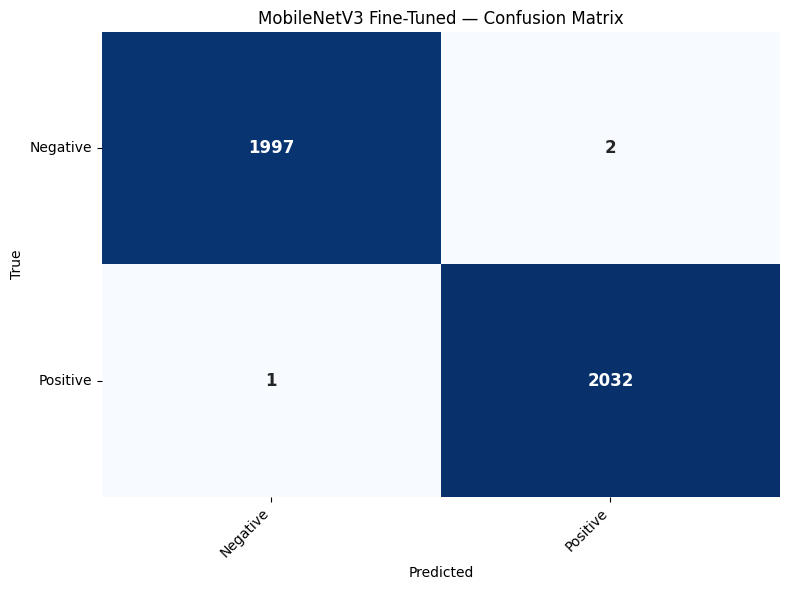

In [ ]:


print("\nEvaluating Fine-Tuned MobileNetV3 on Test Dataset...")
ft_test_acc = evaluate_model(
    tl_model,
    test_dataset,
    class_names,
    'MobileNetV3 Fine-Tuned'
)

In [ ]:

results = {
    'Custom CNN': {
        'acc': cnn_test_acc,
        'params': cnn_model.count_params()
    },
    'MobileNetV3 (TL)': {
        'acc': tl_test_acc,
        'params': tl_model.count_params()
    },
    'MobileNetV3 (FT)': {
        'acc': ft_test_acc,
        'params': tl_model.count_params()
    }
}

print(f'{"Model":<25} {"Test Acc":>10} {"Params":>14}')
print('-' * 55)
for name, vals in results.items():
    print(f'{name:<25} {vals["acc"]:>10.4f} {vals["params"]:>14,}')

Model                       Test Acc         Params
-------------------------------------------------------
Custom CNN                    0.9990        322,338
MobileNetV3 (TL)              0.9993      1,087,346
MobileNetV3 (FT)              0.9993      1,087,346


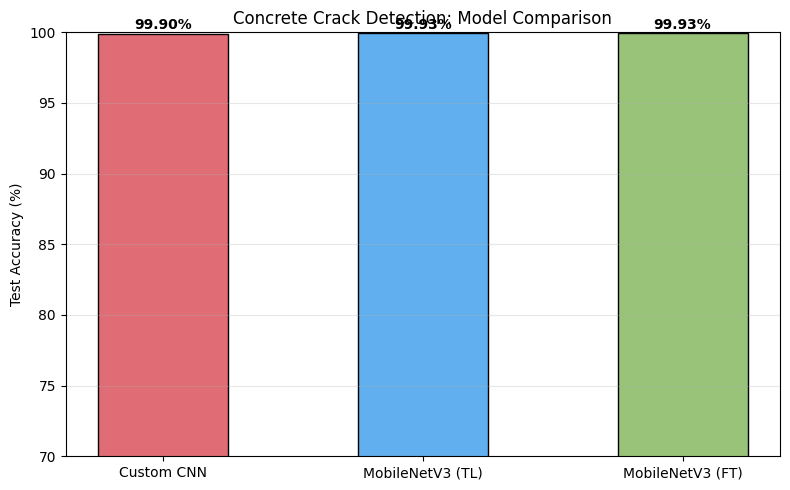

In [ ]:


labels = list(results.keys())
accs = [v['acc'] * 100 for v in results.values()]

colors = ['#e06c75', '#61afef', '#98c379']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, accs, color=colors, edgecolor='black', width=0.5)

ax.set_ylim(70, 100)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Concrete Crack Detection: Model Comparison')
ax.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{acc:.2f}%',
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig('lab8_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

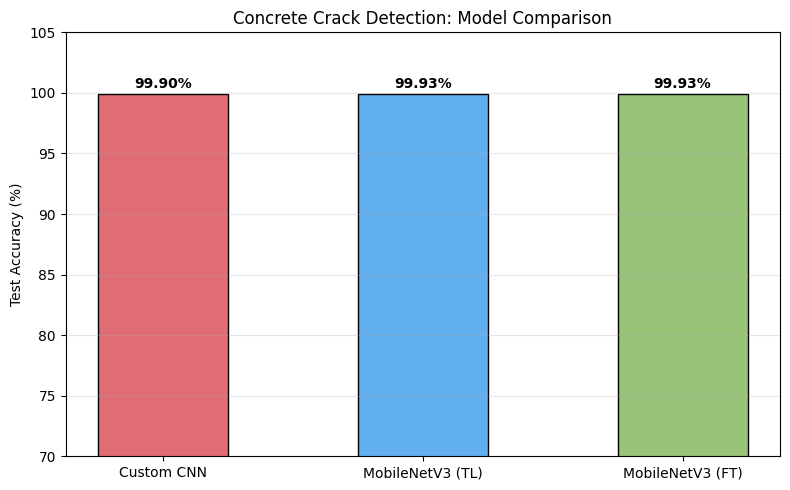

In [ ]:


labels = list(results.keys())
accs = [v['acc'] * 100 for v in results.values()]

colors = ['#e06c75', '#61afef', '#98c379']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, accs, color=colors[:len(labels)], edgecolor='black', width=0.5)

ax.set_ylim(70, 105)
ax.set_ylabel('Test Accuracy (%)')

ax.set_title('Concrete Crack Detection: Model Comparison')
ax.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{acc:.2f}%',
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.savefig('concrete_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def predict_image(img_path, models_dict, class_names, image_size=(128, 128)):
    """Load an image file and classify it with each model in models_dict."""
    img = tf.keras.utils.load_img(img_path, target_size=image_size)
    img_array = tf.keras.utils.img_to_array(img)

    img_array = np.expand_dims(img_array, axis=0) # (1, H, W, 3)

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Input Image')
    plt.show()

    print(f'\nPredictions for: {img_path}')
    print('-' * 40)
    for name, mdl in models_dict.items():
        preds = mdl.predict(img_array, verbose=0)[0]

        if len(preds) == 1:
            prob = preds[0]
            label = class_names[int(prob >= 0.5)]
        else:
            prob = np.max(preds)
            label = class_names[np.argmax(preds)]

        print(f'{name:<25}: {label} (confidence={prob:.4f})')




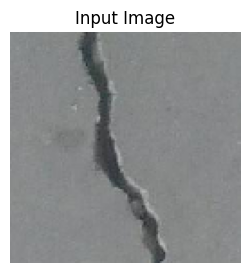


Predictions for: /kaggle/input/datasets/arunrk7/surface-crack-detection/Positive/00001.jpg
----------------------------------------
Custom CNN               : Positive (confidence=1.0000)
MobileNetV3 TL           : Positive (confidence=1.0000)


In [ ]:

test_image_path = '/kaggle/input/datasets/arunrk7/surface-crack-detection/Positive/00001.jpg'

try:
    predict_image(
        test_image_path,
        {'Custom CNN': cnn_model, 'MobileNetV3 TL': tl_model},
        class_names
    )
except FileNotFoundError:
    print(f"Waiting for you to update the image path! Could not find: {test_image_path}")




In [ ]:

results_dir = "results/Cracked/"
if not os.path.exists(results_dir):
    os.makedirs(results_dir, exist_ok=True)

cnn_model.save(f'{results_dir}custom_cnn.keras')
tl_model.save(f'{results_dir}mobilenetv3_transfer.keras')

print(f'Models saved successfully to the {results_dir} folder:')
print(f' -> {results_dir}custom_cnn.keras')
print(f' -> {results_dir}mobilenetv3_transfer.keras')

Models saved successfully to the results/Cracked/ folder:
 -> results/Cracked/custom_cnn.keras
 -> results/Cracked/mobilenetv3_transfer.keras


In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import tensorflow as tf
from PIL import Image


st.set_page_config(
    page_title="Concrete Crack Detector",
    page_icon="🔧",
    layout="centered",
)


st.title("Concrete Surface Crack Detector")
st.subheader("Concrete Bridge Deck Crack Detection (Cracked vs Non-Cracked)")
st.caption("Upload an image of a concrete surface to analyze it for structural cracks.")
st.divider()

@st.cache_resource
def load_model():
    return tf.keras.models.load_model("mobilenetv3_transfer.keras")

model = load_model()


def predict(model, pil_image):
    img = pil_image.convert("RGB").resize((128, 128))
    arr = np.expand_dims(np.array(img, dtype=np.float32), axis=0)
    preds = model.predict(arr, verbose=0)[0]

    # Class mapping based on alphabetical folder order:
    # Index 0: 'Negative' (No Crack)
    # Index 1: 'Positive' (Crack)
    prob_negative = float(preds[0])
    prob_positive = float(preds[1])


    if prob_positive >= prob_negative:
        label = "Crack Detected"
    else:
        label = "No Crack (Clean)"

    return label, prob_positive, prob_negative


uploaded_file = st.file_uploader("Choose a concrete image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    img = Image.open(uploaded_file)


    st.image(img, caption="Uploaded Image", width=350)

    if st.button("Scan Concrete slab", type="primary"):
        with st.spinner("Scanning for anomalies..."):
            label, prob_positive, prob_negative = predict(model, img)


        if label == "Crack Detected":
            st.error(f"Result: **{label}**")
        else:
            st.success(f"Result: **{label}**")

        st.divider()


        st.write("### Scanning Image")
        col1, col2 = st.columns(2)


        with col1:
            st.metric(label="Cracked (Positive)", value=f"{prob_positive * 100:.2f}%")
            st.progress(prob_positive)

        with col2:
            st.metric(label="Clean (Negative)", value=f"{prob_negative * 100:.2f}%")
            st.progress(prob_negative)

Writing app.py


In [ ]:
!pip install -q streamlit
!npm install localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 73.4 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 88.1 MB/s eta 0:00:00:00:010:01
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
added 22 packages in 2s
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼npm notice
npm notice New major version of npm available! 10.8.2 -> 12.0.2
npm notice Changelog: https://github.com/npm/cli/releases/tag/v12.0.2
npm notice To update run: npm install -g npm@12.0.2
npm notice
⠼

In [ ]:
!curl ipv4.icanhazip.com

34.67.230.106


In [ ]:
import os
import time
import subprocess

os.system("pkill -f streamlit")
os.system("pkill -f cloudflared")
time.sleep(2)

!wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared

print("Starting Streamlit server...")
subprocess.Popen([
    "streamlit", "run", "app.py",
    "--server.port", "8501",
    "--server.address", "0.0.0.0",
    "--server.headless", "true"
])

time.sleep(5)

print("Opening Cloudflare tunnel...")
!./cloudflared tunnel --url http://localhost:8501

Starting Streamlit server...




2026-07-30 05:55:03.789 Uvicorn server started on 0.0.0.0:8501



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.19.2.2:8501
  External URL: http://34.67.230.106:8501

Opening Cloudflare tunnel...
2026-07-30T05:55:06Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-07-30T05:55:06Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-07-30T05:55:10Z INF +--------------------------------------------------------------------------------------------+

I0000 00:00:1785394926.255293    4074 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6514 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785394926.257657    4074 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13638 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


  Stopping...
^C
2026-07-30T07:17:02Z INF Initiating graceful shutdown due to signal interrupt ...
2026-07-30T07:17:02Z ERR failed to run the datagram handler error="context canceled" connIndex=0 event=0 ip=198.41.192.167
2026-07-30T07:17:02Z ERR failed to serve tunnel connection error="accept stream listener encountered a failure while serving" connIndex=0 event=0 ip=198.41.192.167
2026-07-30T07:17:02Z ERR Serve tunnel error error="accept stream listener encountered a failure while serving" connIndex=0 event=0 ip=198.41.192.167
2026-07-30T07:17:02Z INF Retrying connection in up to 1s connIndex=0 event=0 ip=198.41.192.167
2026-07-30T07:17:02Z ERR Connection terminated connIndex=0
2026-07-30T07:17:02Z ERR no more connections active and exiting
2026-07-30T07:17:02Z INF Tunnel server stopped
2026-07-30T07:17:02Z INF Metrics server stopped
